In [71]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('bonn_eeg.csv')
df.head()


,signal_0,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,...,signal_4088,signal_4089,signal_4090,signal_4091,signal_4092,signal_4093,signal_4094,signal_4095,signal_4096,label
0,23.0,17.0,10.0,10.0,7.0,-5.0,-6.0,-13.0,-19.0,-26.0,...,8.0,13.0,16.0,24.0,34.0,42.0,41.0,39.0,-55.0,F
1,26.0,29.0,26.0,22.0,18.0,8.0,-1.0,-16.0,-26.0,-31.0,...,55.0,62.0,60.0,63.0,69.0,65.0,49.0,32.0,-150.0,F
2,-142.0,-142.0,-133.0,-126.0,-123.0,-112.0,-100.0,-91.0,-93.0,-95.0,...,-150.0,-161.0,-172.0,-183.0,-192.0,-201.0,-200.0,-202.0,-153.0,F
3,88.0,77.0,69.0,56.0,45.0,35.0,21.0,-8.0,-33.0,-44.0,...,-32.0,24.0,82.0,133.0,176.0,190.0,176.0,146.0,-35.0,F
4,-24.0,-27.0,-23.0,-28.0,-34.0,-40.0,-47.0,-43.0,-38.0,-23.0,...,-15.0,-24.0,-32.0,-50.0,-70.0,-67.0,-57.0,-33.0,-52.0,F


In [4]:
df.tail()

,signal_0,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,...,signal_4088,signal_4089,signal_4090,signal_4091,signal_4092,signal_4093,signal_4094,signal_4095,signal_4096,label
395,36.0,27.0,24.0,12.0,6.0,-11.0,-22.0,-21.0,-10.0,-3.0,...,32.0,65.0,97.0,100.0,88.0,80.0,66.0,59.0,6.0,Z
396,56.0,55.0,38.0,-5.0,-47.0,-72.0,-79.0,-62.0,-39.0,-21.0,...,-3.0,36.0,41.0,14.0,-27.0,-45.0,-32.0,-4.0,69.0,Z
397,-51.0,-42.0,-39.0,-47.0,-51.0,-46.0,-29.0,-7.0,9.0,10.0,...,23.0,-7.0,-16.0,-18.0,-9.0,2.0,-2.0,0.0,-49.0,Z
398,-3.0,-3.0,-12.0,-24.0,-34.0,-42.0,-41.0,-49.0,-20.0,7.0,...,-4.0,31.0,54.0,61.0,55.0,42.0,30.0,19.0,-64.0,Z
399,-36.0,-71.0,-120.0,-150.0,-160.0,-133.0,-96.0,-56.0,-28.0,-39.0,...,31.0,39.0,57.0,44.0,41.0,14.0,3.0,-13.0,30.0,Z


## Exploring Data

In [5]:
df.shape

(400, 4098)

In [6]:
df.describe()

,signal_0,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,...,signal_4087,signal_4088,signal_4089,signal_4090,signal_4091,signal_4092,signal_4093,signal_4094,signal_4095,signal_4096
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.00000,400.000000,400.000000,400.00000
mean,-1.08000,-8.640000,-15.927500,-18.900000,-15.972500,-10.047500,-2.992500,2.552500,7.705000,11.127500,...,-3.620000,-1.400000,-0.032500,-0.137500,-1.37000,-0.610000,1.87500,2.630000,0.697500,-20.62500
std,160.39795,180.607359,208.794613,223.397731,209.540712,182.449595,169.319358,171.180677,171.445375,171.108259,...,204.137628,190.923452,183.259123,184.384742,196.28402,201.259874,192.44811,164.790193,131.760514,240.60223
min,-985.00000,-1221.000000,-1406.000000,-1395.000000,-1291.000000,-880.000000,-998.000000,-1156.000000,-1009.000000,-665.000000,...,-1583.000000,-1224.000000,-1094.000000,-1400.000000,-1697.00000,-1547.000000,-1120.00000,-1073.000000,-734.000000,-1852.00000
25%,-48.25000,-54.000000,-52.000000,-52.000000,-53.000000,-58.000000,-53.250000,-55.250000,-53.250000,-52.000000,...,-52.000000,-48.000000,-44.000000,-48.000000,-55.25000,-65.250000,-61.00000,-56.000000,-52.250000,-57.00000
50%,-7.00000,-7.500000,-6.000000,-5.000000,-6.000000,-4.000000,-2.000000,-3.500000,-1.000000,-0.500000,...,-8.000000,-9.000000,-7.000000,-11.500000,-8.00000,-8.500000,-7.50000,-6.000000,-5.500000,-11.00000
75%,43.00000,43.000000,42.250000,45.250000,45.250000,44.250000,42.500000,42.000000,41.500000,43.000000,...,38.000000,38.250000,39.000000,44.250000,47.25000,48.250000,49.25000,44.000000,38.250000,33.00000
max,800.00000,839.000000,857.000000,876.000000,893.000000,928.000000,973.000000,1045.000000,1381.000000,1502.000000,...,925.000000,911.000000,914.000000,919.000000,916.00000,829.000000,781.00000,703.000000,677.000000,1002.00000


In [21]:
print("Overall Signal Statistics:")

mean_min = stats_summary['mean'].min()
mean_max = stats_summary['mean'].max()

std_min = stats_summary['std'].min()
std_max = stats_summary['std'].max()

min_min = stats_summary['min'].min()
min_max = stats_summary['min'].max()

max_min = stats_summary['max'].min()
max_max = stats_summary['max'].max()

print("Mean range:", round(mean_min, 2), "to", round(mean_max, 2))
print("Std range:", round(std_min, 2), "to", round(std_max, 2))
print("Min range:", round(min_min, 2), "to", round(min_max, 2))
print("Max range:", round(max_min, 2), "to", round(max_max, 2))

Overall Signal Statistics:
Mean range: -47.15 to 27.8
Std range: 129.08 to 283.15
Min range: -1885.0 to -413.0
Max range: 473.0 to 2047.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Columns: 4098 entries, signal_0 to label
dtypes: float64(4097), object(1)
memory usage: 12.5+ MB


In [12]:
# Missing values
missing_count = df.isnull().sum().sum()
print("Missing Values:", missing_count)


Missing Values: 0


In [13]:
# Data types
signal_cols = [c for c in df.columns if c != 'label']

print("\nData Types:")
print("Signal Columns:", len(signal_cols), "(float values)")
print("Label Column: 1")


Data Types:
Signal Columns: 4097 (float values)
Label Column: 1


###  Label Distribution Analysis

In [22]:
df['label'].nunique()

4

In [25]:
label_counts = df['label'].value_counts().sort_index()
label_props = df['label'].value_counts(normalize=True).sort_index()


In [31]:
print("\nClass Counts:")
print("Class 0:", label_counts.values[0], "samples")
print("Class 1:", label_counts.values[1], "samples")
print("Class 2:", label_counts.values[2], "samples")
print("Class 3:", label_counts.values[3], "samples")

print("\nClass Percentages:")
print("Class 0:", round(label_props.values[0]*100, 1), "%")
print("Class 1:", round(label_props.values[1]*100, 1), "%")
print("Class 2:", round(label_props.values[2]*100, 1), "%")
print("Class 3:", round(label_props.values[3]*100, 1), "%")

print("\nDataset is balanced")
print("Each class has:", label_counts.values[0], "samples")


Class Counts:
Class 0: 100 samples
Class 1: 100 samples
Class 2: 100 samples
Class 3: 100 samples

Class Percentages:
Class 0: 25.0 %
Class 1: 25.0 %
Class 2: 25.0 %
Class 3: 25.0 %

Dataset is balanced
Each class has: 100 samples


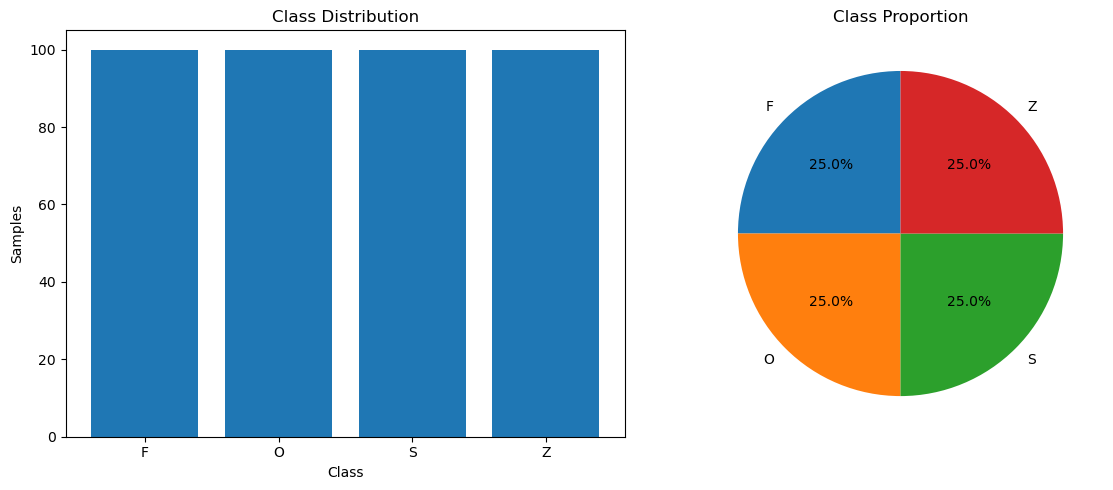

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(label_counts.index, label_counts.values)
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Samples")

axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


###  Dataset Insight
- 400 samples with 4,097 EEG signal features
- High-dimensional data (4,097 features)

**Class Imbalance:**
-  **NO imbalance**: Each class has exactly 100 samples (25% each)

**Feature Characteristics:**
- **Time-series data**: 4,097 consecutive EEG signal measurements
- **Raw signals**: Not pre-extracted features

---------

### Data Preparation 

In [36]:
# features and labels
X = df.drop('label', axis=1).values
y = df['label'].values

In [37]:
# encode labels
label_mapping = {'F': 0, 'O': 1, 'S': 2, 'Z': 3}
y_encoded = np.array([label_mapping[l] for l in y])

In [38]:
print("Feature shape:", X.shape)
print("Label shape:", y_encoded.shape)

Feature shape: (400, 4097)
Label shape: (400,)


In [39]:
print("Label mapping:", label_mapping)

Label mapping: {'F': 0, 'O': 1, 'S': 2, 'Z': 3}


In [40]:
print("\nClass counts after encoding:")
print("F:", (y_encoded == 0).sum())
print("O:", (y_encoded == 1).sum())
print("S:", (y_encoded == 2).sum())
print("Z:", (y_encoded == 3).sum())



Class counts after encoding:
F: 100
O: 100
S: 100
Z: 100


### Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)


print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 280
Test samples: 120


### Preprocessing Pipelines

In [55]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy import signal as sp_signal
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

#### Pipeline A

In [53]:
def pipeline_A(X_train, X_test, y_train):
    print("Processing Pipeline A")

    # Step 1: normalization
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print("Step 1 done: normalization")

    # Step 2: noise removal
    sos = sp_signal.butter(4, 0.2, output='sos')

    X_train = np.array([sp_signal.sosfilt(sos, x) for x in X_train])
    X_test = np.array([sp_signal.sosfilt(sos, x) for x in X_test])

    print("Step 2 done: noise removal")

    # Step 3: feature selection
    selector = SelectKBest(score_func=f_classif, k=500)

    X_train = selector.fit_transform(X_train, y_train)
    X_test = selector.transform(X_test)

    print("Step 3 done: feature selection")

    return X_train, X_test, selector


# run pipeline A
X_train_A, X_test_A, selector_A = pipeline_A(X_train, X_test, y_train)

print("Pipeline A finished")
print("Train shape:", X_train_A.shape)
print("Test shape:", X_test_A.shape)

Processing Pipeline A
Step 1 done: normalization
Step 2 done: noise removal
Step 3 done: feature selection
Pipeline A finished
Train shape: (280, 500)
Test shape: (120, 500)


---------

#### Pipeline B

In [56]:
def extract_statistical_features(X, window_size=512):
    n_samples, n_features = X.shape
    n_windows = n_features // window_size

    features = []

    for sample in X:
        sample_features = []

        for w in range(n_windows):
            start = w * window_size
            end = start + window_size
            window = sample[start:end]

            sample_features += [
                np.mean(window),
                np.std(window),
                np.max(window),
                np.min(window),
                np.percentile(window, 25),
                np.percentile(window, 75),
                np.max(np.abs(window))
            ]

        features.append(sample_features)

    return np.array(features)


def pipeline_B(X_train, X_test, y_train):
    print("Processing Pipeline B")

    # Step 1: feature extraction
    X_train_feat = extract_statistical_features(X_train, 512)
    X_test_feat = extract_statistical_features(X_test, 512)

    print("Step 1 done: feature extraction")

    # Step 2: scaling
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)

    print("Step 2 done: scaling")

    # Step 3: PCA
    pca = PCA(n_components=min(50, X_train_scaled.shape[1] - 1))
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print("Step 3 done: PCA")

    return X_train_pca, X_test_pca, pca


# run pipeline B
X_train_B, X_test_B, pca_B = pipeline_B(X_train, X_test, y_train)

print("Pipeline B finished")
print("Train shape:", X_train_B.shape)
print("Test shape:", X_test_B.shape)

Processing Pipeline B
Step 1 done: feature extraction
Step 2 done: scaling
Step 3 done: PCA
Pipeline B finished
Train shape: (280, 50)
Test shape: (120, 50)


------------

#### Compare Preprocessing Pipelines

In [58]:
print("PREPROCESSING PIPELINE COMPARISON")

# Pipeline A
input_dim = X_train.shape[1]
output_A = X_train_A.shape[1]
reduction_A = ((input_dim - output_A) / input_dim) * 100

print("\nPipeline A")
print("Input shape:", X_train.shape)
print("Output shape:", X_train_A.shape)
print("Reduction:", f"{reduction_A:.1f}%")
print("Method: signal processing + feature selection")

# Pipeline B
output_B = X_train_B.shape[1]
reduction_B = ((input_dim - output_B) / input_dim) * 100

print("\nPipeline B")
print("Input shape:", X_train.shape)
print("Output shape:", X_train_B.shape)
print("Reduction:", f"{reduction_B:.1f}%")
print("Method: feature extraction + PCA")

print("\nKey difference:")
print("- Pipeline A uses original signal features")
print("- Pipeline B creates new feature space first")

PREPROCESSING PIPELINE COMPARISON

Pipeline A
Input shape: (280, 4097)
Output shape: (280, 500)
Reduction: 87.8%
Method: signal processing + feature selection

Pipeline B
Input shape: (280, 4097)
Output shape: (280, 50)
Reduction: 98.8%
Method: feature extraction + PCA

Key difference:
- Pipeline A uses original signal features
- Pipeline B creates new feature space first


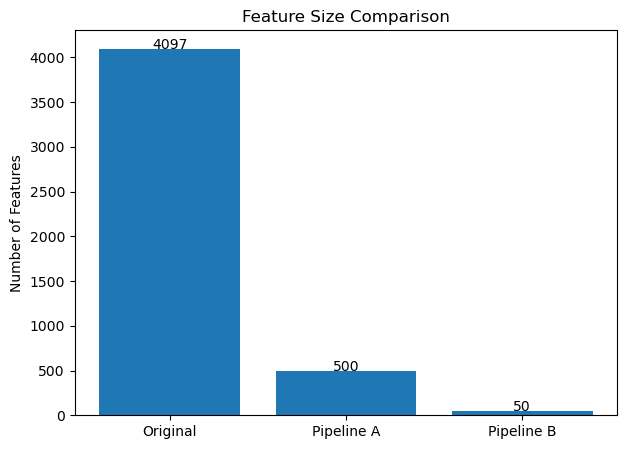

In [59]:
# Feature size comparison plot

labels = ["Original", "Pipeline A", "Pipeline B"]
values = [X_train.shape[1], X_train_A.shape[1], X_train_B.shape[1]]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.title("Feature Size Comparison")
plt.ylabel("Number of Features")

for i in range(len(values)):
    plt.text(i, values[i], str(values[i]), ha='center')

plt.show()

-------

### Baseline Model - Logistic Regression
**Train Baseline Models (No Regularization)**

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix
from sklearn.metrics import roc_curve, classification_report

In [66]:
def train_and_evaluate(X_train, X_test, y_train, y_test, model_name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    pr_auc = []
    for i in range(4):
        y_binary = (y_test == i).astype(int)
        prec, rec, _ = precision_recall_curve(y_binary, y_pred_proba[:, i])
        pr_auc.append(auc(rec, prec))

    return accuracy, f1, precision, recall, np.mean(pr_auc), y_pred

**Pipeline A**

In [67]:
print("Training Model - Pipeline A")

acc_A, f1_A, prec_A, rec_A, pr_AUC_A, pred_A = train_and_evaluate(
    X_train_A, X_test_A, y_train, y_test,
    "A",
    LogisticRegression(max_iter=1000, random_state=42)
)

print("\nResults - Pipeline A")
print("Accuracy:", round(acc_A, 4))
print("F1 Score:", round(f1_A, 4))
print("Precision:", round(prec_A, 4))
print("Recall:", round(rec_A, 4))
print("PR-AUC:", round(pr_AUC_A, 4))

Training Model - Pipeline A

Results - Pipeline A
Accuracy: 0.4333
F1 Score: 0.4074
Precision: 0.5496
Recall: 0.4333
PR-AUC: 0.3857


---------

**Pipeline B**

In [68]:
print("\nTraining Model - Pipeline B")

acc_B, f1_B, prec_B, rec_B, pr_AUC_B, pred_B = train_and_evaluate(
    X_train_B, X_test_B, y_train, y_test,
    "B",
    LogisticRegression(max_iter=1000, random_state=42)
)

print("\nResults - Pipeline B")
print("Accuracy:", round(acc_B, 4))
print("F1 Score:", round(f1_B, 4))
print("Precision:", round(prec_B, 4))
print("Recall:", round(rec_B, 4))
print("PR-AUC:", round(pr_AUC_B, 4))


Training Model - Pipeline B

Results - Pipeline B
Accuracy: 0.6333
F1 Score: 0.625
Precision: 0.6243
Recall: 0.6333
PR-AUC: 0.6723


----

**Comparison**

In [69]:
print("\nMODEL COMPARISON")

print("\nAccuracy A:", round(acc_A, 4))
print("Accuracy B:", round(acc_B, 4))

print("\nDifference:", abs(acc_A - acc_B))

print("\nPipeline A uses 500 features")
print("Pipeline B uses 100 features")
print("Pipeline B is more compact")


MODEL COMPARISON

Accuracy A: 0.4333
Accuracy B: 0.6333

Difference: 0.19999999999999996

Pipeline A uses 500 features
Pipeline B uses 100 features
Pipeline B is more compact


_________

**Confusion Matrices**

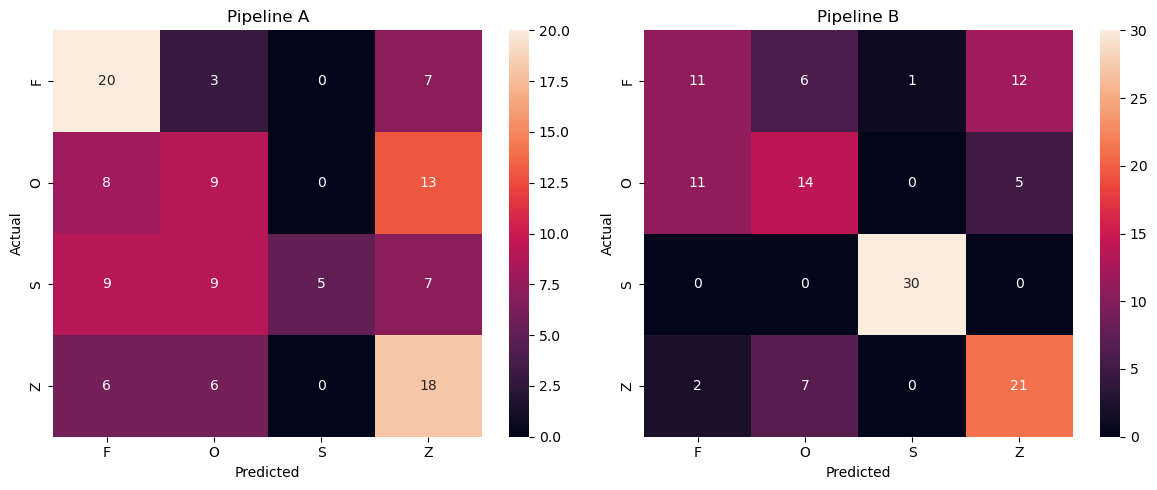

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pipeline A
cm_A = confusion_matrix(y_test, pred_A)

sns.heatmap(
    cm_A,
    annot=True,
    fmt='d',
    ax=axes[0],
    xticklabels=['F', 'O', 'S', 'Z'],
    yticklabels=['F', 'O', 'S', 'Z']
)

axes[0].set_title("Pipeline A")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Pipeline B
cm_B = confusion_matrix(y_test, pred_B)

sns.heatmap(
    cm_B,
    annot=True,
    fmt='d',
    ax=axes[1],
    xticklabels=['F', 'O', 'S', 'Z'],
    yticklabels=['F', 'O', 'S', 'Z']
)

axes[1].set_title("Pipeline B")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300)
plt.show()



-------

### Overfitting & Underfitting Analysis

**Create Underfitting Scenario**

In [77]:
# using only first 50 features
X_train_A_small = X_train_A[:, :50]
X_test_A_small = X_test_A[:, :50]

# model
underfit_A = LogisticRegression(C=0.001, max_iter=1000, random_state=42)

underfit_A.fit(X_train_A_small, y_train)

y_pred_underfit_A = underfit_A.predict(X_test_A_small)

# metrics
underfit_acc = accuracy_score(y_test, y_pred_underfit_A)
underfit_f1 = f1_score(y_test, y_pred_underfit_A, average='weighted')
underfit_prec = precision_score(y_test, y_pred_underfit_A, average='weighted')
underfit_rec = recall_score(y_test, y_pred_underfit_A, average='weighted')

print("\nUnderfit Model Results")
print("Accuracy:", round(underfit_acc, 4))
print("F1 Score:", round(underfit_f1, 4))
print("Precision:", round(underfit_prec, 4))
print("Recall:", round(underfit_rec, 4))


Underfit Model Results
Accuracy: 0.45
F1 Score: 0.4494
Precision: 0.46
Recall: 0.45


-------

**Create Overfitting Scenario**

In [78]:
# model
overfit_model = LogisticRegression(C=1000, max_iter=5000, random_state=42)

overfit_model.fit(X_train, y_train)

# predictions
train_pred = overfit_model.predict(X_train)
test_pred = overfit_model.predict(X_test)

# metrics
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_f1 = f1_score(y_train, train_pred, average='weighted')
test_f1 = f1_score(y_test, test_pred, average='weighted')

print("\nOverfit Model Results")

print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Accuracy Gap:", round(train_acc - test_acc, 4))

print("\nTrain F1 Score:", round(train_f1, 4))
print("Test F1 Score:", round(test_f1, 4))
print("F1 Gap:", round(train_f1 - test_f1, 4))


Overfit Model Results
Train Accuracy: 1.0
Test Accuracy: 0.425
Accuracy Gap: 0.575

Train F1 Score: 1.0
Test F1 Score: 0.4077
F1 Gap: 0.5923


-------

**Learning Curves**

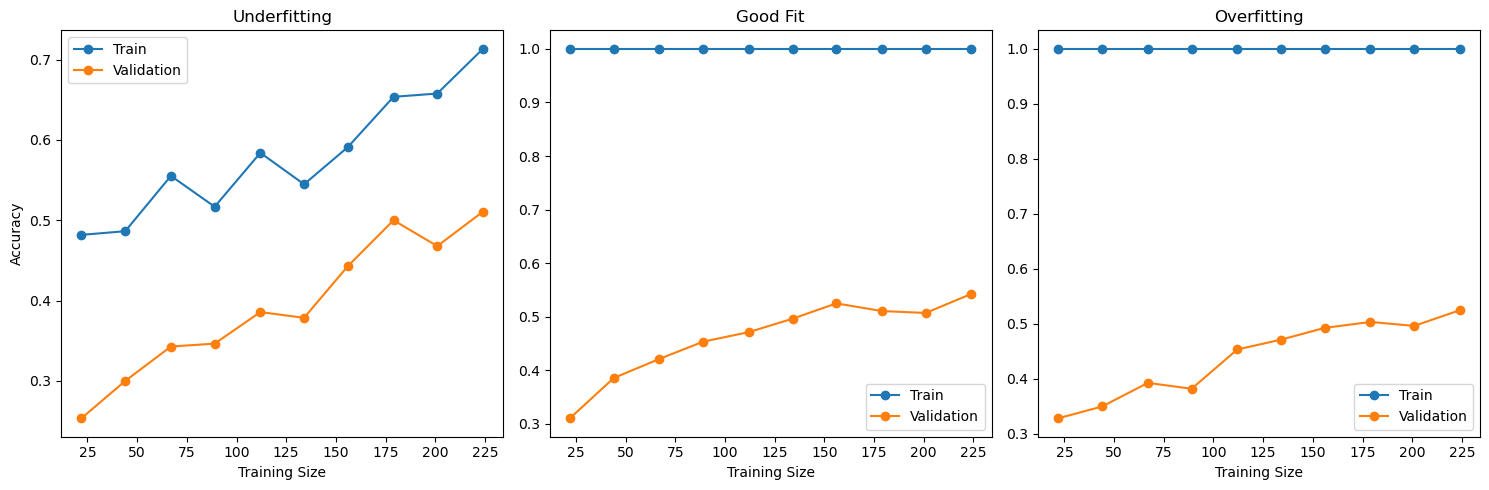

In [79]:
# Underfitting
train_sizes, train_scores_underfit, val_scores_underfit = learning_curve(
    LogisticRegression(C=0.001, max_iter=1000, random_state=42),
    X_train_A,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Baseline
train_sizes, train_scores_base, val_scores_base = learning_curve(
    LogisticRegression(C=1, max_iter=1000, random_state=42),
    X_train_A,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Overfitting
train_sizes, train_scores_over, val_scores_over = learning_curve(
    LogisticRegression(C=1000, max_iter=5000, random_state=42),
    X_train,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# mean scores
underfit_train = np.mean(train_scores_underfit, axis=1)
underfit_val = np.mean(val_scores_underfit, axis=1)

base_train = np.mean(train_scores_base, axis=1)
base_val = np.mean(val_scores_base, axis=1)

over_train = np.mean(train_scores_over, axis=1)
over_val = np.mean(val_scores_over, axis=1)

# plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Underfit
axes[0].plot(train_sizes, underfit_train, marker='o', label='Train')
axes[0].plot(train_sizes, underfit_val, marker='o', label='Validation')
axes[0].set_title("Underfitting")
axes[0].set_xlabel("Training Size")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Good fit
axes[1].plot(train_sizes, base_train, marker='o', label='Train')
axes[1].plot(train_sizes, base_val, marker='o', label='Validation')
axes[1].set_title("Good Fit")
axes[1].set_xlabel("Training Size")
axes[1].legend()

# Overfit
axes[2].plot(train_sizes, over_train, marker='o', label='Train')
axes[2].plot(train_sizes, over_val, marker='o', label='Validation')
axes[2].set_title("Overfitting")
axes[2].set_xlabel("Training Size")
axes[2].legend()

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=300)
plt.show()

In [81]:
print("MODEL ANALYSIS")

under_gap = abs(underfit_train[-1] - underfit_val[-1])
base_gap = abs(base_train[-1] - base_val[-1])
over_gap = abs(over_train[-1] - over_val[-1])

print("\nUnderfitting")
print("Train-Val Gap:", round(under_gap, 4))
print("Validation Accuracy:", round(underfit_val[-1], 4))

print("\nGood Fit")
print("Train-Val Gap:", round(base_gap, 4))
print("Validation Accuracy:", round(base_val[-1], 4))

print("\nOverfitting")
print("Train-Val Gap:", round(over_gap, 4))
print("Validation Accuracy:", round(over_val[-1], 4))

MODEL ANALYSIS

Underfitting
Train-Val Gap: 0.2027
Validation Accuracy: 0.5107

Good Fit
Train-Val Gap: 0.4571
Validation Accuracy: 0.5429

Overfitting
Train-Val Gap: 0.475
Validation Accuracy: 0.525


----------

### Regularization Study

**Train Models with Different Regularizations**

In [84]:
results = {
    "C": [],
    "L2_acc": [], "L2_f1": [],
    "L1_acc": [], "L1_f1": [],
    "Elastic_acc": [], "Elastic_f1": []
}
for C in C_values:
    print("C =", C)

    # L2
    l2 = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=5000, random_state=42)
    l2.fit(X_train_A, y_train)
    pred_l2 = l2.predict(X_test_A)

    acc_l2 = accuracy_score(y_test, pred_l2)
    f1_l2 = f1_score(y_test, pred_l2, average='weighted')

    # L1
    l1 = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=5000, random_state=42)
    l1.fit(X_train_A, y_train)
    pred_l1 = l1.predict(X_test_A)

    acc_l1 = accuracy_score(y_test, pred_l1)
    f1_l1 = f1_score(y_test, pred_l1, average='weighted')

    # Elastic Net
    elastic = LogisticRegression(
        penalty='elasticnet',
        C=C,
        solver='saga',
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42
    )
    elastic.fit(X_train_A, y_train)
    pred_elastic = elastic.predict(X_test_A)

    acc_elastic = accuracy_score(y_test, pred_elastic)
    f1_elastic = f1_score(y_test, pred_elastic, average='weighted')

    # store results
    results["C"].append(C)

    results["L2_acc"].append(acc_l2)
    results["L2_f1"].append(f1_l2)

    results["L1_acc"].append(acc_l1)
    results["L1_f1"].append(f1_l1)

    results["Elastic_acc"].append(acc_elastic)
    results["Elastic_f1"].append(f1_elastic)

    print("done")

C = 0.001
done
C = 0.01
done
C = 0.1
done
C = 1
done
C = 10
done
C = 100
done
C = 1000
done


**Regularization Results Table**

In [85]:
results_df = pd.DataFrame({
    "C": results["C"],
    "L2_acc": results["L2_acc"],
    "L2_f1": results["L2_f1"],
    "L1_acc": results["L1_acc"],
    "L1_f1": results["L1_f1"],
    "Elastic_acc": results["Elastic_acc"],
    "Elastic_f1": results["Elastic_f1"]
})

print("REGULARIZATION RESULTS\n")
print(results_df.to_string(index=False))

REGULARIZATION RESULTS

       C   L2_acc    L2_f1   L1_acc    L1_f1  Elastic_acc  Elastic_f1
   0.001 0.408333 0.412843 0.250000 0.100000     0.250000    0.100000
   0.010 0.441667 0.445545 0.250000 0.100000     0.250000    0.100000
   0.100 0.425000 0.419077 0.408333 0.417781     0.441667    0.448754
   1.000 0.433333 0.407362 0.425000 0.430556     0.433333    0.434087
  10.000 0.441667 0.415849 0.458333 0.458771     0.433333    0.414503
 100.000 0.475000 0.463871 0.425000 0.411522     0.433333    0.414503
1000.000 0.433333 0.436289 0.416667 0.389477     0.433333    0.414503


-------

**Regularization Visualization**

**Accuracy vs C**

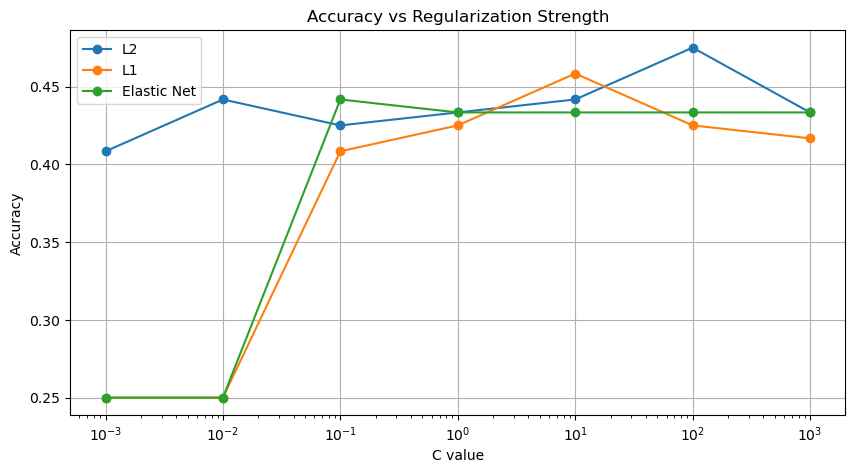

In [86]:
plt.figure(figsize=(10, 5))

plt.plot(results["C"], results["L2_acc"], marker='o', label="L2")
plt.plot(results["C"], results["L1_acc"], marker='o', label="L1")
plt.plot(results["C"], results["Elastic_acc"], marker='o', label="Elastic Net")

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Regularization Strength")
plt.legend()
plt.grid(True)

plt.show()

**F1 Score vs C**

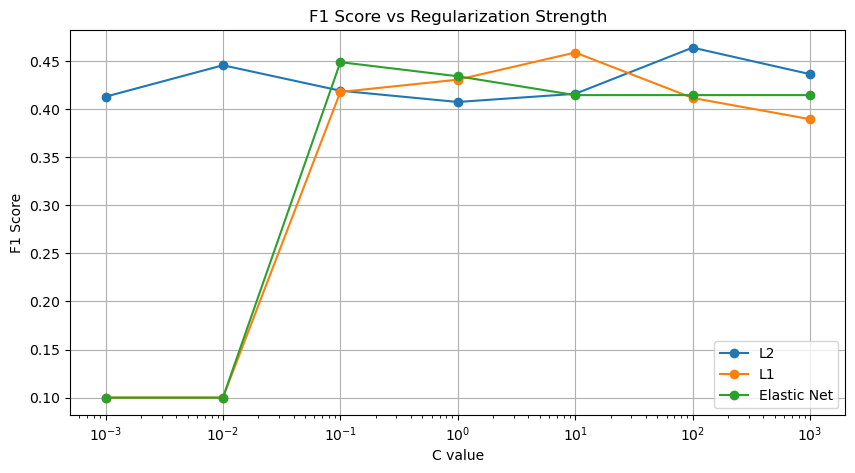

In [87]:
plt.figure(figsize=(10, 5))

plt.plot(results["C"], results["L2_f1"], marker='o', label="L2")
plt.plot(results["C"], results["L1_f1"], marker='o', label="L1")
plt.plot(results["C"], results["Elastic_f1"], marker='o', label="Elastic Net")

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Regularization Strength")
plt.legend()
plt.grid(True)

plt.show()

**Best Model Comparison**

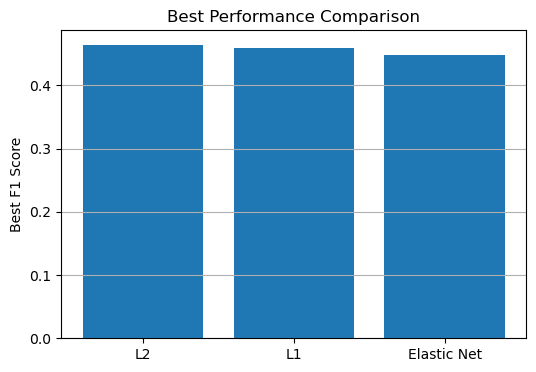

In [88]:
best_l2 = max(results["L2_f1"])
best_l1 = max(results["L1_f1"])
best_elastic = max(results["Elastic_f1"])

models = ["L2", "L1", "Elastic Net"]
scores = [best_l2, best_l1, best_elastic]

plt.figure(figsize=(6, 4))
plt.bar(models, scores)

plt.ylabel("Best F1 Score")
plt.title("Best Performance Comparison")
plt.grid(axis='y')

plt.show()

__________

**SPARSITY ANALYSIS**

In [89]:
print("SPARSITY ANALYSIS (L1)")

sparsity_results = []

for C in C_values:
    model = LogisticRegression(
        penalty='l1',
        C=C,
        solver='liblinear',
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_A, y_train)

    total_features = X_train_A.shape[1]

    zero_count = (model.coef_ == 0).sum()
    nonzero_count = total_features * model.coef_.shape[0] - zero_count

    sparsity = (zero_count / (total_features * model.coef_.shape[0])) * 100

    sparsity_results.append([C, nonzero_count, zero_count, sparsity])

sparsity_df = pd.DataFrame(
    sparsity_results,
    columns=["C", "Non_zero", "Zero", "Sparsity_%"]
)

print("\nResults")
print(sparsity_df.to_string(index=False))

SPARSITY ANALYSIS (L1)

Results
       C  Non_zero  Zero  Sparsity_%
   0.001         0  2000      100.00
   0.010         0  2000      100.00
   0.100        71  1929       96.45
   1.000       364  1636       81.80
  10.000       477  1523       76.15
 100.000       673  1327       66.35
1000.000      1048   952       47.60


**Non-zero features vs C**

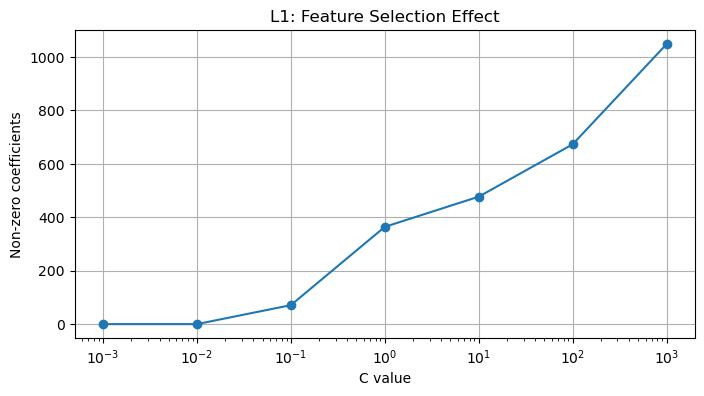

In [90]:
plt.figure(figsize=(8, 4))

plt.semilogx(sparsity_df["C"], sparsity_df["Non_zero"], marker='o')

plt.xlabel("C value")
plt.ylabel("Non-zero coefficients")
plt.title("L1: Feature Selection Effect")
plt.grid(True)

plt.show()

**Sparsity %**

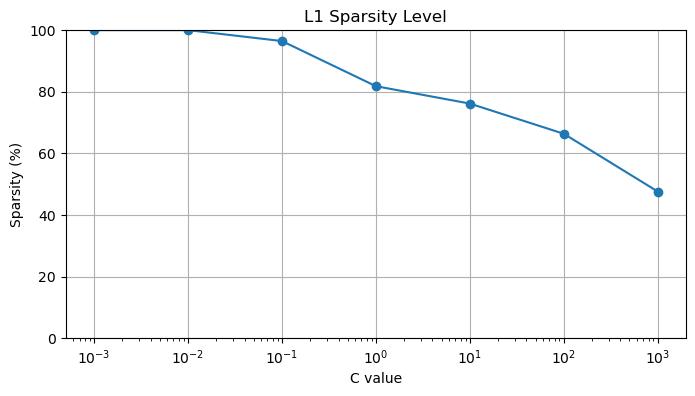

In [91]:
plt.figure(figsize=(8, 4))

plt.semilogx(sparsity_df["C"], sparsity_df["Sparsity_%"], marker='o')

plt.xlabel("C value")
plt.ylabel("Sparsity (%)")
plt.title("L1 Sparsity Level")
plt.ylim(0, 100)
plt.grid(True)

plt.show()

________

### Class Imbalance Handling

In [95]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [93]:
imbalance_results = {}

**SMOTE**

In [96]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_A, y_train)

model = LogisticRegression(C=1, max_iter=1000, random_state=42)
model.fit(X_smote, y_smote)

pred = model.predict(X_test_A)

imbalance_results["SMOTE"] = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, average="weighted"),
    "recall": recall_score(y_test, pred, average="weighted"),
    "f1": f1_score(y_test, pred, average="weighted")
}

**UnderSampling**

In [97]:
under = RandomUnderSampler(random_state=42)
X_under, y_under = under.fit_resample(X_train_A, y_train)

model = LogisticRegression(C=1, max_iter=1000, random_state=42)
model.fit(X_under, y_under)

pred = model.predict(X_test_A)

imbalance_results["Undersampling"] = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, average="weighted"),
    "recall": recall_score(y_test, pred, average="weighted"),
    "f1": f1_score(y_test, pred, average="weighted")
}

**ClassWeight**

In [98]:
model = LogisticRegression(C=1, class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_A, y_train)

pred = model.predict(X_test_A)

imbalance_results["Class_Weight"] = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, average="weighted"),
    "recall": recall_score(y_test, pred, average="weighted"),
    "f1": f1_score(y_test, pred, average="weighted")
}

**BaseLine**

In [99]:
model = LogisticRegression(C=1, max_iter=1000, random_state=42)
model.fit(X_train_A, y_train)

pred = model.predict(X_test_A)

imbalance_results["Baseline"] = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, average="weighted"),
    "recall": recall_score(y_test, pred, average="weighted"),
    "f1": f1_score(y_test, pred, average="weighted")
}

**RESULTS TABLE**

In [100]:
imbalance_df = pd.DataFrame(imbalance_results).T
print("RESULTS")
print(imbalance_df)

RESULTS
               accuracy  precision    recall        f1
SMOTE          0.433333   0.549612  0.433333  0.407362
Undersampling  0.433333   0.549612  0.433333  0.407362
Class_Weight   0.433333   0.549612  0.433333  0.407362
Baseline       0.433333   0.549612  0.433333  0.407362


**Analysis**

In [101]:
for m, v in imbalance_results.items():
    print("\n", m)
    print("Acc:", round(v["accuracy"], 4))
    print("F1:", round(v["f1"], 4))


 SMOTE
Acc: 0.4333
F1: 0.4074

 Undersampling
Acc: 0.4333
F1: 0.4074

 Class_Weight
Acc: 0.4333
F1: 0.4074

 Baseline
Acc: 0.4333
F1: 0.4074


_______